# Objectif du notebook 

Date de création :30/03/2026

À compléter 


In [1]:
# %matplotlib notebook

import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import scipy.signal as sp 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.interpolate import interp1d
from scipy.spatial.distance import cdist
from datetime import timedelta, datetime
from scipy.stats import linregress
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

sensibility_img_folder = os.path.join(img_folder, "rtf_mfp", "sensibility")

In [3]:
sys.path.append(project_root)
from publication.publication_figure import (
    PubFigure,
    LargeFigure,
    color,
    set_subfigures_abc_labels,
)
from propa.rtf.rtf_utils import D_hermitian_angle_fast, D_euclidian


from real_data_analysis.fiberscope_groix.src.fiberscope_groix_manager import (
    # ActiveFiberscopeManager,
    # PassiveFiberscopeManager,
    BandFilter,
)

from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp import (
    RTF_MFP_Processor,
)

In [4]:
root_data = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data"
root_img = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\img\rtf_mfp"
ref_rcv_id = 2
rtf_estimator = "cs-evd"

tau_ir_hat = 0.2  # estimated impulse response duration from sequence 144
tau_ir_hat *= 2  # To ensure we include the entire response


fsm_active_kwargs = {
    "bandfilter": BandFilter(order=4, lowcut=100, highcut=900),
    "tau_ir": tau_ir_hat,
    "process_pulse_one_by_one": True,
    "estimate_ir_duration": False,
}
fsm_passive_kwargs = {
    "analysis_segment_duration": 5,
    "analysis_segment_alpha_overlap": 0,
}

fsm_props = {
    "fs": 2000,
    "tau_rtf_analysis": 3,
    "alpha_overlap": 0.5,
}

rtf_mfp_processor = RTF_MFP_Processor(
    root_data=root_data,
    root_img=root_img,
    reference_receiver_id=ref_rcv_id,
    rtf_estimator=rtf_estimator,
    fsm_props=fsm_props,
    fsm_active_kwargs=fsm_active_kwargs,
    fsm_passive_kwargs=fsm_passive_kwargs,
    mode="overwrite",
    plot_replicas_features=False,
    verbose=True,
)

In [5]:
rtf_mfp_processor.fsm_passive.cm.nperseg

4096

In [6]:
rtf_mfp_processor.fsm_nperseg

8192

# Étape 1 : sélection d'une sous partie de la séquence

Afin de simplifier l'étude, la séquence est réduite aux émissions comprises entre l'OBS 1 et l'OBS 3 (émissions n°50 à n°170).

In [7]:
# Load GPS dataset for station coordinates
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))

# Load arrivals dataset
fpath = os.path.join(
    data_folder,
    f"processed_arrivals.nc",
)
ds_arr = xr.open_dataset(fpath)
df_arr = ds_arr.to_dataframe()

In [8]:
seq_id = 144
df_seq = df_arr.loc[df_arr["sequence_id"] == seq_id]

# Select only pulses emitted between OBS1 and OBS3
pulse_slice = (50, 170)
df_seq = df_seq.loc[df_seq["pulse_id"].between(*pulse_slice)]

root_fig = os.path.join(sensibility_img_folder, f"{seq_id}")
if not os.path.exists(root_fig):
    os.makedirs(root_fig)

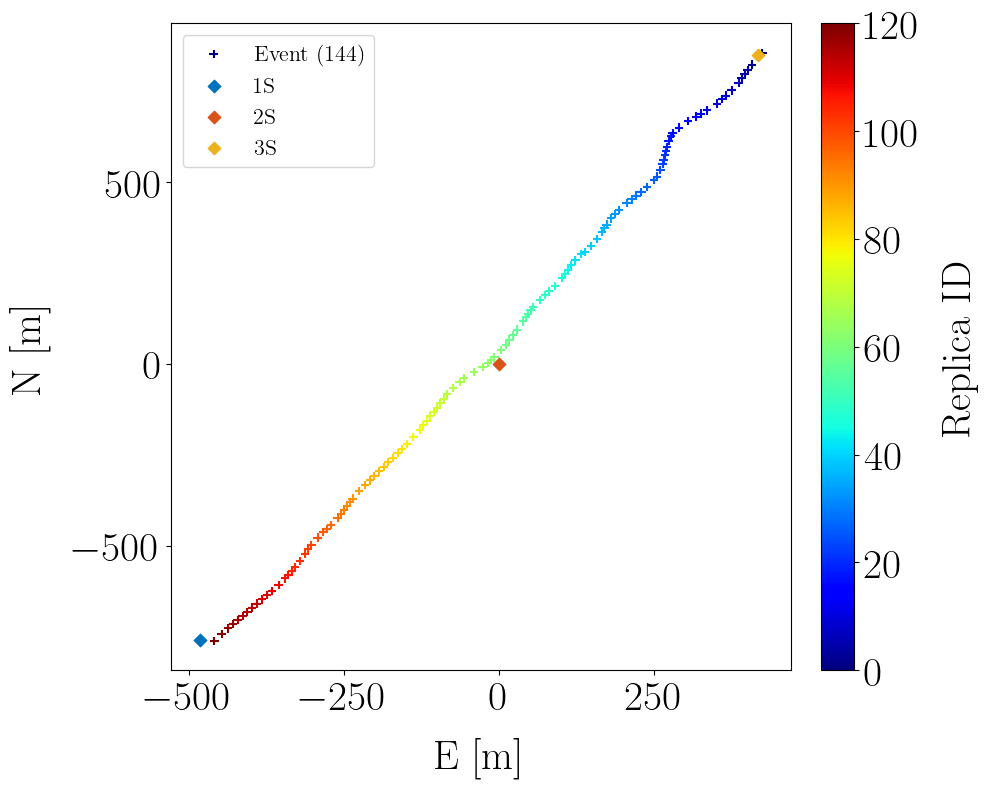

In [9]:
# Tracer des positions d'émission et des positions des OBS sur la carte

pfig = PubFigure(size=(10, 8), legend_fontsize=16)
# Plot
plt.figure()

# Série de positions successives
plt.scatter(
    df_seq["emission_interp_e_gps"],
    df_seq["emission_interp_n_gps"],
    marker="+",
    label=f"Event ({seq_id})",
    c=np.arange(df_seq["emission_interp_e_gps"].size),
    cmap="jet",
)
plt.colorbar(label="Replica ID")


keys = ["obs1", "obs2", "obs3"]
label = {
    "obs1": "1S",
    "obs2": "2S",
    "obs3": "3S",
    "t1": "1",
    "t2": "2",
    "t3": "3",
    "t4": "4",
    "t5": "5",
}
for ik, k in enumerate(keys):
    e = ds_gps.attrs[f"{k}_e_apriori"]
    n = ds_gps.attrs[f"{k}_n_apriori"]
    plt.scatter(
        e,
        n,
        marker="D",
        label=label[k],
        zorder=10,
        color=color(ik),
        s=40,
    )

plt.legend()
plt.xlabel("E [m]")
plt.ylabel("N [m]")

fpath = os.path.join(root_fig, "emission_positions.png")
plt.savefig(fpath)

# Étape 2 : choix des paramètres de l'estimateur CS-EVD 

Le succès de la méthode proposée repose en grande partie sur la capacité à estimer correctement la grandeur signante d'intérêt, à savoir le vecteur de RTFs. 

Dans le cas de signaux actifs, le vecteur de RTFs peut également être estimé par déconvolution du signal reçu. Pour chaque émission considérée, le vecteur de RTF estimée par déconvolution est utilisé comme référence et comparé au vecteur de RTF estimé par la méthode CS-EVD et ce, pour différents paramètres de l'estimateur CS-EVD. 

In [10]:
root_data = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data"
root_img = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\img\rtf_mfp"
ref_rcv_id = 2
rtf_estimator = "cs-evd"

tau_ir_hat = 0.2  # estimated impulse response duration from sequence 144
tau_ir_hat *= 2  # To ensure we include the entire response


fsm_active_kwargs = {
    "bandfilter": None,
    "tau_ir": tau_ir_hat,
    "process_pulse_one_by_one": True,
    "estimate_ir_duration": False,
}
fsm_passive_kwargs = {
    "analysis_segment_duration": 5,
    "analysis_segment_alpha_overlap": 0,
}

fsm_props = {
    "fs": 2000,
    "tau_rtf_analysis": 3,
    "alpha_overlap": 0.5,
}

rtf_mfp_processor = RTF_MFP_Processor(
    root_data=root_data,
    root_img=root_img,
    reference_receiver_id=ref_rcv_id,
    rtf_estimator=rtf_estimator,
    fsm_props=fsm_props,
    fsm_active_kwargs=fsm_active_kwargs,
    fsm_passive_kwargs=fsm_passive_kwargs,
    mode="overwrite",
    plot_replicas_features=False,
    verbose=True,
)

In [11]:
###########################
# Dummy 
###########################
id_library = 100

active_replicas_args = {
    "replica_sequence_ids": [144],
    "replica_pulse_slice": [pulse_slice],
    "load_precomputed_feature": False,
}

passive_replicas_args = {
    "start_datetimes": [],
    "end_datetimes": [],
    "load_precomputed_feature": True,
}

rtf_mfp_processor.compute_library(
    active_feature_args=active_replicas_args,
    passive_feature_args=passive_replicas_args,
    id=id_library,
)


Deriving features for active source...

RTF processing of sequences [144] (nb of sequences = 1)
Progress: ████████████████████████████████████████████████████████████████████████████████████████████████████ 100%
RTF feature estimation for sequence 144
Progress: ████████████████████████████████████████████████████████████████████████████████████████████████████ 100%
Deriving replicas for passive source...
A library dataset with ID 100 already exists in C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library. This library dataset will be overwritten.
Dataset (library) saved at C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library\library_100.nc.


In [111]:
fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library\library_100.nc"
ds = xr.open_dataset(fpath)
ds

<xarray.Dataset> Size: 30MB
Dimensions:           (h_index: 3, f_rtf: 4097, replica_id: 121, f_deconv: 5401)
Coordinates:
  * h_index           (h_index) int32 12B 1 2 3
  * f_rtf             (f_rtf) float32 16kB 0.0 0.2441 0.4883 ... 999.8 1e+03
  * replica_id        (replica_id) int32 484B 0 1 2 3 4 ... 116 117 118 119 120
  * f_deconv          (f_deconv) float32 22kB 0.0 0.1852 0.3703 ... 999.7 999.9
Data variables:
    rtf_amp           (h_index, f_rtf, replica_id) float32 6MB ...
    rtf_phase         (h_index, f_rtf, replica_id) float32 6MB ...
    rtf_amp_deconv    (h_index, f_deconv, replica_id) float32 8MB ...
    rtf_phase_deconv  (h_index, f_deconv, replica_id) float32 8MB ...
    feature_psd       (f_rtf, replica_id) float32 2MB ...
    e_replica         (replica_id) float32 484B ...
    n_replica         (replica_id) float32 484B ...
    u_replica         (replica_id) float32 484B ...
    replica_type      (replica_id) int32 484B ...
Attributes: (12/16)
    reference_receiver_id:  2
    rtf_estimator:          cs-evd
    replica_type_1:         active
    replica_type_2:         passive
    description:            Library dataset containing RTF-MFP features for a...
    type:                   library
    ...                     ...
    obs2_n_apriori:         0.0
    obs2_u_apriori:         0.0
    obs3_e_apriori:         418.25417297268984
    obs3_n_apriori:         850.5744968832777
    obs3_u_apriori:         -7.991059774156952
    id:                     100

In [123]:
# Select frequency range
fmin = 550
fmax = 650
ds = ds.sel(f_rtf=slice(fmin, fmax), f_deconv=slice(fmin, fmax))
freq = ds.f_rtf.values
freq_deconv = ds.f_deconv.values

# Build complex RTFs
rtf_cs_evd = ds.rtf_amp * np.exp(1j * ds.rtf_phase)
rtf_deconvolution = ds.rtf_amp_deconv * np.exp(1j * ds.rtf_phase_deconv)

# Interpolate rtf_deconv at rtf frequencies
# Interp module
interpolator_module = interp1d(
    freq_deconv, ds.rtf_amp_deconv.values, axis=1, fill_value="extrapolate"
)
rtf_deconvolution_module_interp = interpolator_module(freq)

# Interp unwrapped phase
unwrapped_phase_deconv = np.unwrap(ds.rtf_phase_deconv.values, axis=1)
interpolator_phase = interp1d(
    freq_deconv, unwrapped_phase_deconv, axis=1, fill_value="extrapolate"
)
rtf_deconvolution_phase_unwrapped_interp = interpolator_phase(freq)
# Wrap the interpolated unwrapped phase back to [-pi, pi]
rtf_deconvolution_phase_interp = (rtf_deconvolution_phase_unwrapped_interp + np.pi) % (2 * np.pi) - np.pi

# Build interpolated complex RTF
rtf_deconvolution_interp = rtf_deconvolution_module_interp * np.exp(1j * rtf_deconvolution_phase_interp)

In [124]:
np.allclose(
    rtf_deconvolution_phase_unwrapped_interp, np.unwrap(rtf_deconvolution_phase_interp)
)

False

False
False


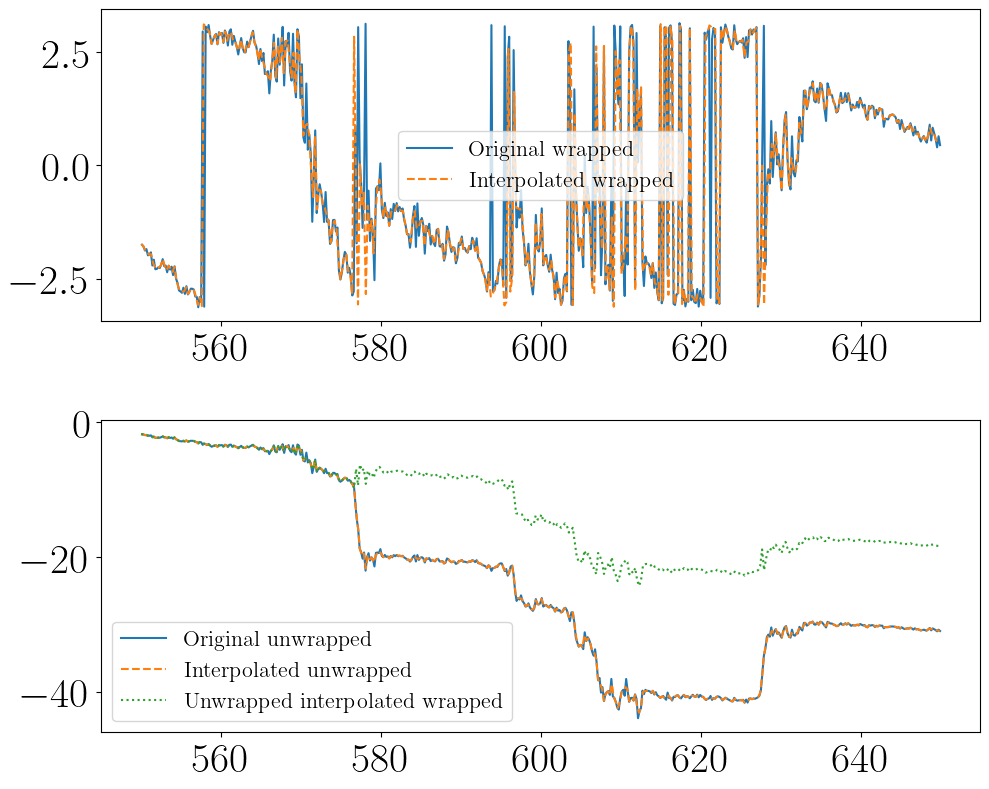

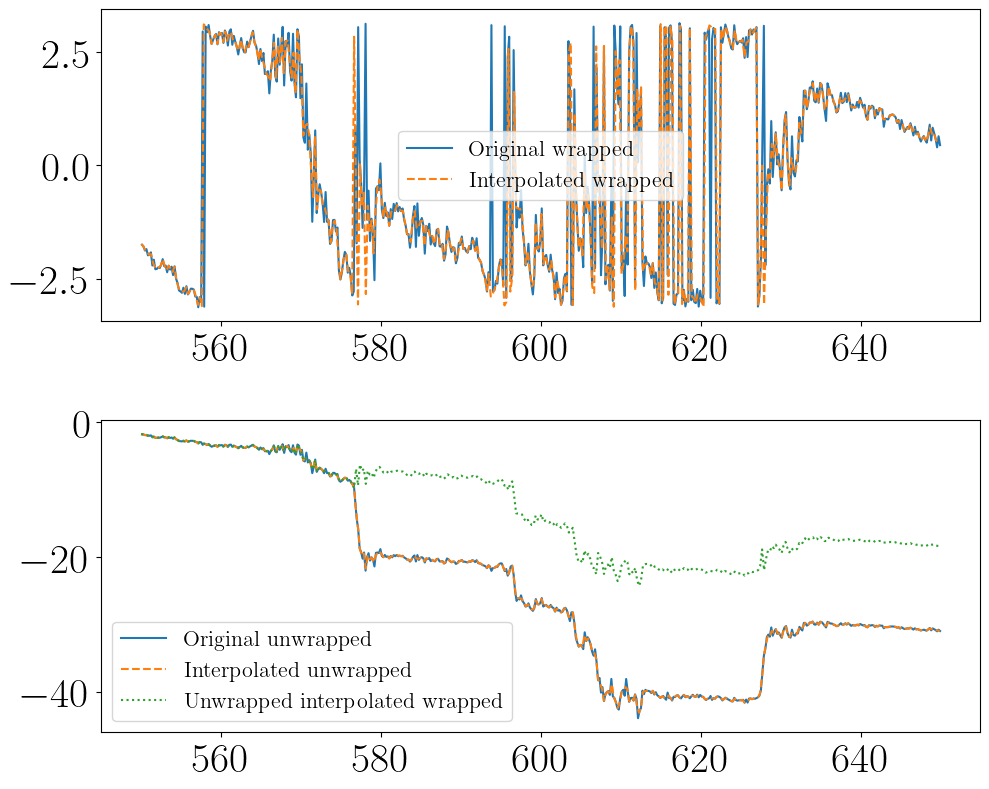

In [125]:
# Test
# n = 1000
# f = np.linspace(fmin, fmax, n)
# f_interp = np.linspace(fmin, fmax, int(2*n))
# phi = np.random.uniform(low=-np.pi, high=np.pi, size=n)
phi = ds.rtf_phase_deconv.values[0, :, 50]
f = ds.f_deconv.values
f_interp = ds.f_rtf.values

phi_unwrapped = np.unwrap(phi)
interpolator_phase_test = interp1d(
    f, phi_unwrapped, fill_value="extrapolate", kind="linear"
)
phi_unwrapped_interp = interpolator_phase_test(f_interp)
phi_interp = (phi_unwrapped_interp + np.pi) % (2 * np.pi) - np.pi

print(np.allclose(phi_unwrapped_interp, np.unwrap(phi_interp)))
plt.figure()
plt.subplot(2, 1, 1)
plt.plot(f, phi, label="Original wrapped")
plt.plot(f_interp, phi_interp, label="Interpolated wrapped", linestyle="--")
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(f, phi_unwrapped, label="Original unwrapped")
plt.plot(f_interp, phi_unwrapped_interp, label="Interpolated unwrapped", linestyle="--")
plt.plot(f_interp, np.unwrap(phi_interp), label="Unwrapped interpolated wrapped", linestyle=":")
plt.legend()

phi = ds.rtf_phase_deconv.values
f = ds.f_deconv.values
f_interp = ds.f_rtf.values

phi_unwrapped = np.unwrap(phi, axis=1)
interpolator_phase_test = interp1d(
    f, phi_unwrapped, fill_value="extrapolate", kind="linear", axis=1
)
phi_unwrapped_interp = interpolator_phase_test(f_interp)
phi_interp = (phi_unwrapped_interp + np.pi) % (2 * np.pi) - np.pi


print(np.allclose(phi_unwrapped_interp, np.unwrap(phi_interp)))
plt.figure()
plt.subplot(2, 1, 1)
plt.plot(f, phi[0, :, 50], label="Original wrapped")
plt.plot(f_interp, phi_interp[0, :, 50], label="Interpolated wrapped", linestyle="--")
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(f, phi_unwrapped[0, :, 50], label="Original unwrapped")
plt.plot(
    f_interp,
    phi_unwrapped_interp[0, :, 50],
    label="Interpolated unwrapped",
    linestyle="--",
)
plt.plot(
    f_interp,
    np.unwrap(phi_interp[0, :, 50]),
    label="Unwrapped interpolated wrapped",
    linestyle=":",
)
plt.legend()

In [115]:
# # Effect of unwrapping and wrapping
# # phi = ds.rtf_phase.values[0, :, 50]
# # f = freq
# phi = ds.rtf_phase_deconv.values[0, :, 50]
# f = freq_deconv

# phi_unwrapped = np.unwrap(phi)
# phi_unwrapped_wrapped = (phi_unwrapped + np.pi) % (2 * np.pi) - np.pi
# plt.figure(figsize=(12, 6))
# plt.plot(f, phi, label="Original Phase")
# plt.plot(f, phi_unwrapped_wrapped, label="Unwrapped + Wrapped Phase")
# plt.xlabel("Frequency (Hz)")
# plt.ylabel("Phase (radians)")
# plt.title("Effect of Unwrapping and Wrapping Phase")
# plt.legend()

Text(0.5, 0.01, 'Frequency [Hz]')

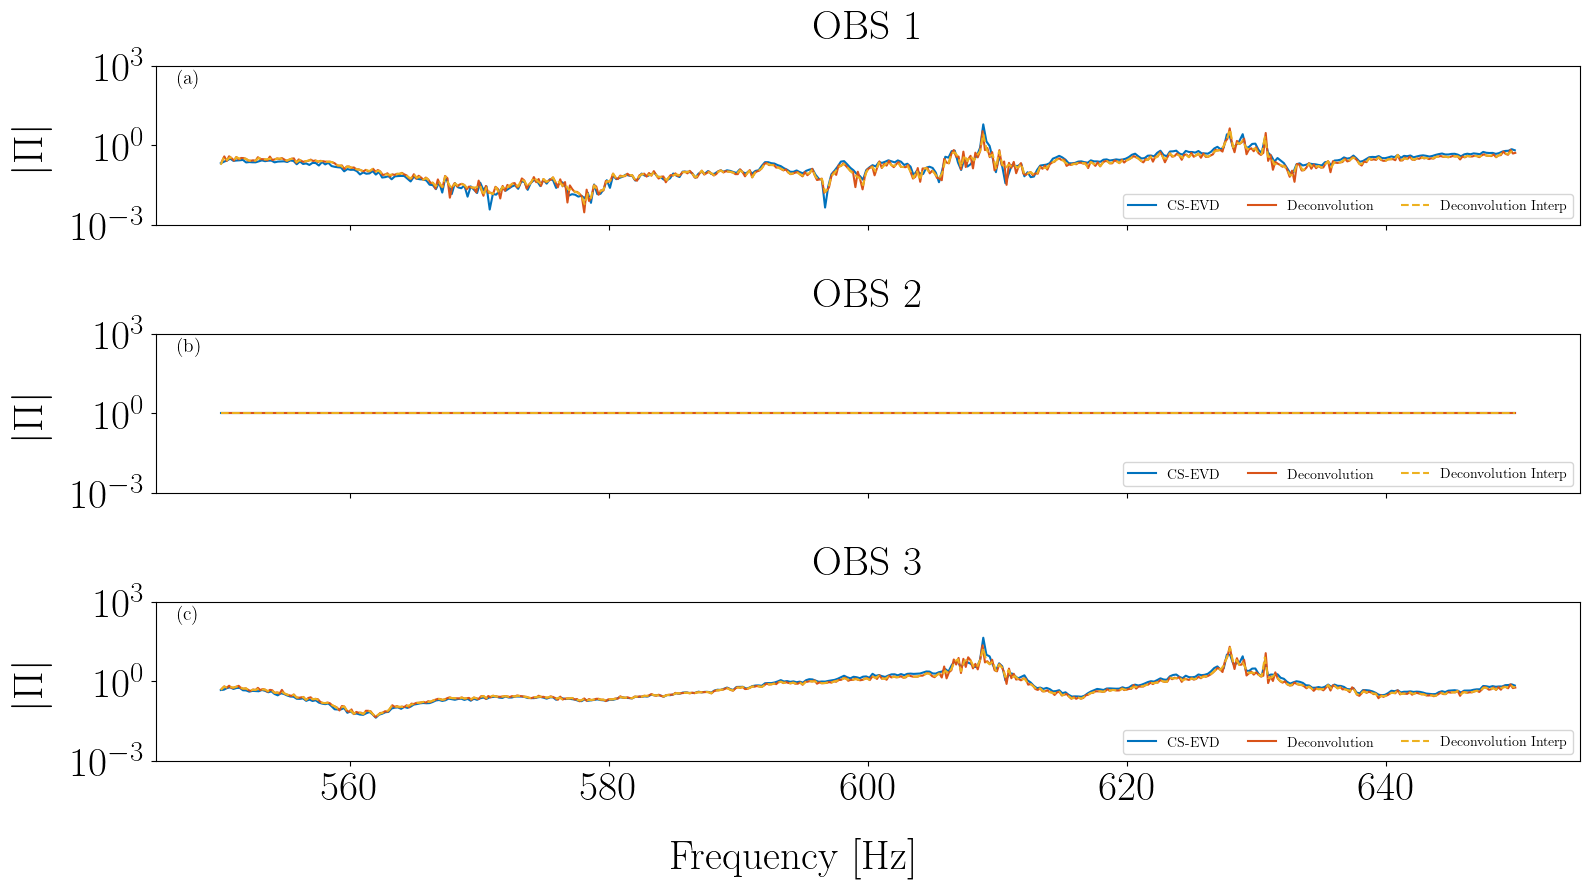

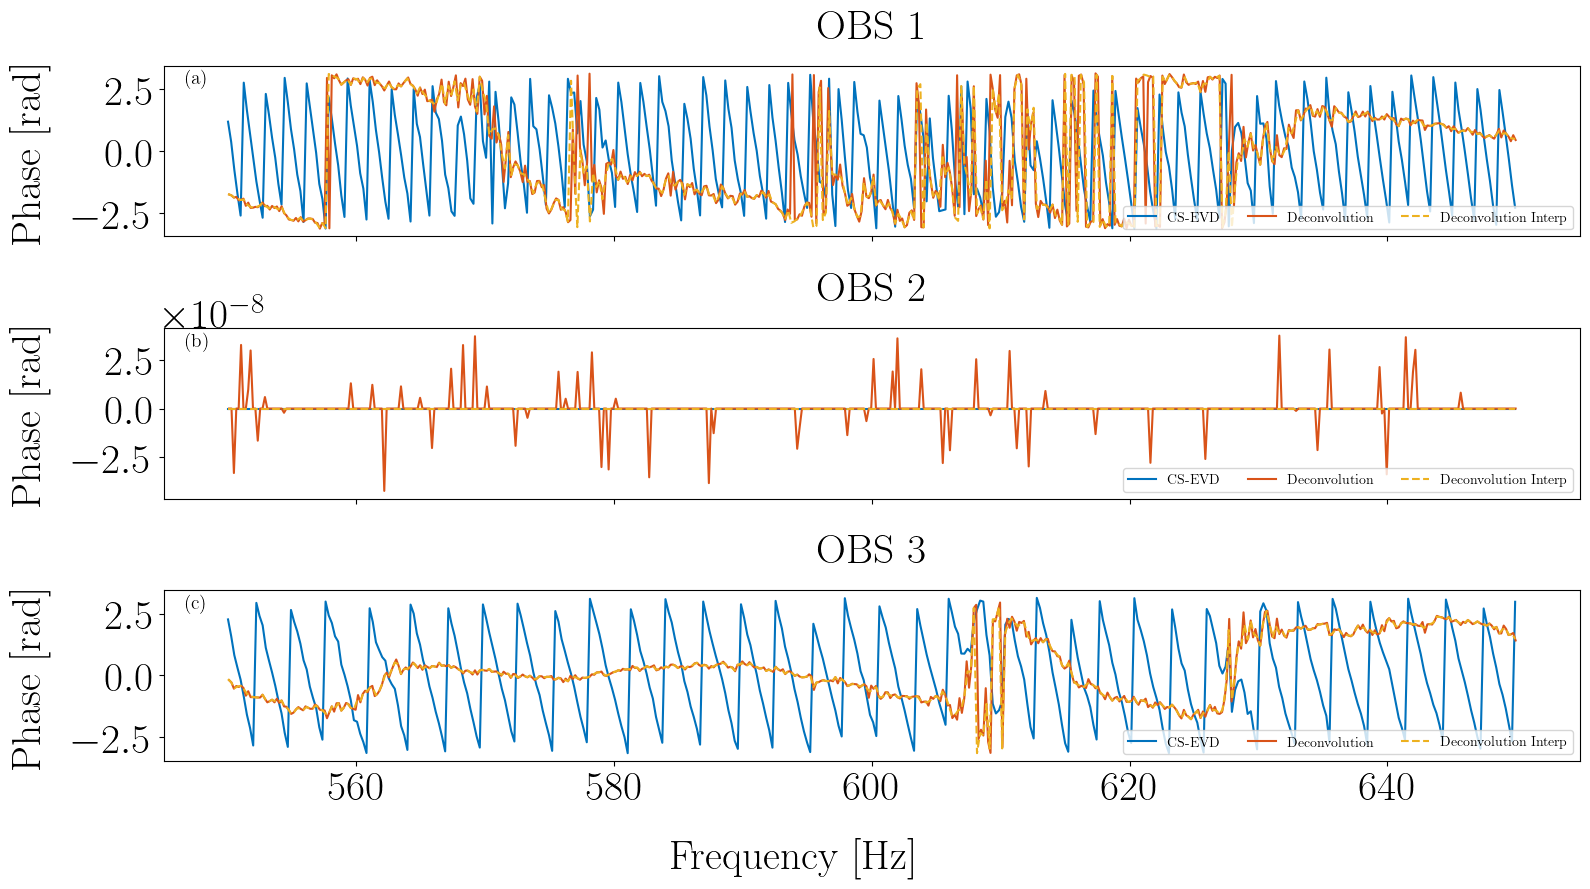

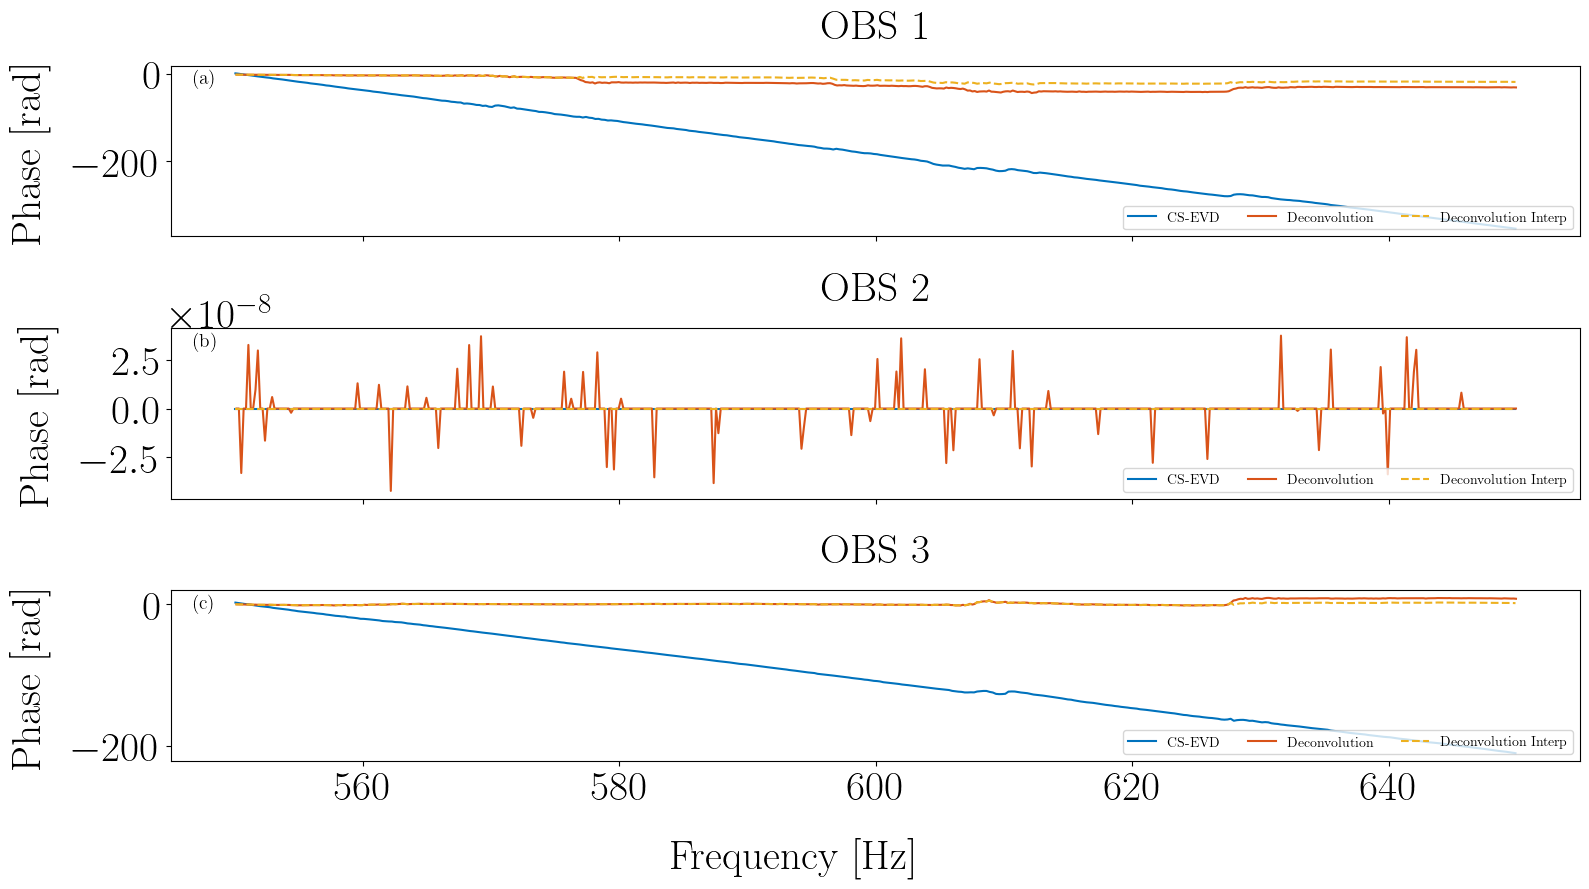

In [129]:
i_pulse = 50
n_rcv = ds.h_index.size
# Compare module
fig, ax_mod = plt.subplots(
    nrows=n_rcv, ncols=1, sharex=True, sharey="row", figsize=(16, 3 * n_rcv)
)


# Module
for i_rcv in range(n_rcv):
    h_plot = i_rcv + 1

    ax_mod[i_rcv].plot(freq, np.abs(rtf_cs_evd[i_rcv, :, i_pulse]), label="CS-EVD", color=color(0))
    ax_mod[i_rcv].plot(
        freq_deconv,
        np.abs(rtf_deconvolution[i_rcv, :, i_pulse]),
        label="Deconvolution",
        color=color(1),
    )
    ax_mod[i_rcv].plot(freq, np.abs(rtf_deconvolution_interp[i_rcv, :, i_pulse]), label="Deconvolution Interp", color=color(2), linestyle="--")

    ax_mod[i_rcv].set_title(f"OBS {h_plot}")
    ax_mod[i_rcv].set_ylim([0.001, 1000])
    ax_mod[i_rcv].set_yscale("log")
    ax_mod[i_rcv].set_xlabel("")
    ax_mod[i_rcv].set_ylabel(r"$|\Pi|$")
    ax_mod[i_rcv].legend(fontsize=10, ncol=3, loc="lower right")

set_subfigures_abc_labels(
    axs=ax_mod, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)
fig.supxlabel("Frequency [Hz]")

# Wrapped phase
fig, ax_phase_wrapped = plt.subplots(
    nrows=n_rcv, ncols=1, sharex=True, sharey="row", figsize=(16, 3 * n_rcv)
)
for i_rcv in range(n_rcv):
    h_plot = i_rcv + 1

    ax_phase_wrapped[i_rcv].plot(freq, np.angle(rtf_cs_evd[i_rcv, :, i_pulse]), label="CS-EVD", color=color(0))
    ax_phase_wrapped[i_rcv].plot(
        freq_deconv,
        np.angle(rtf_deconvolution[i_rcv, :, i_pulse]),
        label="Deconvolution",
        color=color(1),
    )
    ax_phase_wrapped[i_rcv].plot(freq, np.angle(rtf_deconvolution_interp[i_rcv, :, i_pulse]), label="Deconvolution Interp", color=color(2), linestyle="--")
    ax_phase_wrapped[i_rcv].set_title(f"OBS {h_plot}")
    ax_phase_wrapped[i_rcv].set_xlabel("")
    ax_phase_wrapped[i_rcv].set_ylabel(r"Phase [rad]")
    ax_phase_wrapped[i_rcv].legend(fontsize=10, ncol=3, loc="lower right")

set_subfigures_abc_labels(
    axs=ax_phase_wrapped, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)
fig.supxlabel("Frequency [Hz]")

# Unwrapped phase
fig, ax_phase = plt.subplots(
    nrows=n_rcv, ncols=1, sharex=True, sharey="row", figsize=(16, 3 * n_rcv)
)
for i_rcv in range(n_rcv):
    h_plot = i_rcv + 1

    ax_phase[i_rcv].plot(freq, np.unwrap(np.angle(rtf_cs_evd[i_rcv, :, i_pulse])), label="CS-EVD", color=color(0))
    ax_phase[i_rcv].plot(
        freq_deconv,
        np.unwrap(np.angle(rtf_deconvolution[i_rcv, :, i_pulse])),
        label="Deconvolution",
        color=color(1),
    )
    ax_phase[i_rcv].plot(freq, np.unwrap(np.angle(rtf_deconvolution_interp[i_rcv, :, i_pulse])), label="Deconvolution Interp", color=color(2), linestyle="--")


    ax_phase[i_rcv].set_title(f"OBS {h_plot}")
    ax_phase[i_rcv].set_xlabel("")
    ax_phase[i_rcv].set_ylabel(r"Phase [rad]")
    ax_phase[i_rcv].legend(fontsize=10, ncol=3, loc="lower right")

set_subfigures_abc_labels(
    axs=ax_phase, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)
fig.supxlabel("Frequency [Hz]")

Très faible accord 

In [ ]:
###########################
# Library computation
###########################
id_event = 5
id_library = 6

active_replicas_args = {
    "replica_sequence_ids": [144],
    # "replica_pulse_slice": [(35, 75)],
    "replica_pulse_slice": [(100, 140)],
    "load_precomputed_feature": False,
}

passive_replicas_args = {
    "start_datetimes": [
        # datetime(year=2025, month=10, day=14, hour=1, minute=40, second=00),  # OK lib 2, 3, 4,5
        # datetime(year=2025, month=10, day=15, hour=00, minute=12, second=00),  # OK
    ],
    "end_datetimes": [
        # datetime(
        #     year=2025, month=10, day=14, hour=1, minute=50, second=00
        # ),  # OK lib 2, 3, 4,5
        # datetime(year=2025, month=10, day=15, hour=00, minute=25, second=00),  # OK
    ],
    "load_precomputed_feature": True,
}

rtf_mfp_processor.compute_library(
    active_feature_args=active_replicas_args,
    passive_feature_args=passive_replicas_args,
    id=id_library,
    # Rv_global=Rv_library,
)

###########################
# Event computation
###########################

# Derive event
active_feature_args = {
    "replica_sequence_ids": [144],
    # "replica_pulse_slice": [(76, 115)],
    "replica_pulse_slice": [(141, 181)],
    "load_precomputed_feature": False,
}

target_mmsi = None
passive_feature_args = {
    "start_datetimes": [
        # datetime(year=2025, month=10, day=14, hour=16, minute=40, second=00),
        # datetime(year=2025, month=10, day=14, hour=16, minute=44, second=00),
        # datetime(year=2025, month=10, day=14, hour=2, minute=10, second=00),  # OK
    ],
    "end_datetimes": [
        # datetime(year=2025, month=10, day=14, hour=16, minute=50, second=00),
        # datetime(year=2025, month=10, day=14, hour=16, minute=48, second=00),
        # datetime(year=2025, month=10, day=14, hour=2, minute=20, second=00),  # OK
    ],
    "load_precomputed_feature": False,
}

rtf_mfp_processor.compute_event(
    active_feature_args=active_feature_args,
    passive_feature_args=passive_feature_args,
    id=id_event,
    target_mmsi=target_mmsi,
    # Rv_global=Rv_event,
)

###########################
# Matching library and event features
###########################

dist_args = {
    "fmin": 200,
    "fmax": 300,
    "dist_type": "hermitian_angle",
    "use_weighted_mean": False,
}
rtf_mfp_processor.match(id_library=id_library, id_event=id_event, dist_args=dist_args)

In [ ]:
rtf_mfp_processor.fsm_passive.cm.nperseg

In [ ]:
def get_bootstrap_dist(ds, test_replica_id):
    # Select one replica_id to compare using bootstrap
    test_replica = ds.sel(replica_id=test_replica_id)
    # Remove from the rest of the features for bootstraping
    # bootstrap_replica = ds.drop_sel(replica_id=test_replica_id)
    bootstrap_replica = ds

    # Test RTF
    test_replica_rtf = test_replica.rtf_amp * np.exp(1j * test_replica.rtf_phase)

    # Other RTFs
    bootstrap_replica_rtfs = bootstrap_replica.rtf_amp * np.exp(
        1j * bootstrap_replica.rtf_phase
    )

    # Reshape to 4D array to be able to apply distance function : (n_rcv, n_freq, n_segment_dt) -> (n_rcv, n_freq, n_segment_dt, 1)
    bootstrap_replica_rtfs = bootstrap_replica_rtfs.values[..., np.newaxis]

    # Compute dist
    dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": True}
    dist = D_hermitian_angle_fast(
        rtf_ref=test_replica_rtf.values,
        rtf=bootstrap_replica_rtfs,
        **dist_kwargs,
    )

    # # EUCLIDEAN distance
    # d_rcv_1 = np.linalg.norm(
    #     np.abs(test_replica_rtf.sel(h_index=1).values)[:, np.newaxis]
    #     - np.abs(bootstrap_replica_rtfs[0, ...]), axis=0
    # )
    # d_rcv_2 = np.linalg.norm(
    #     np.abs(test_replica_rtf.sel(h_index=2).values)[:, np.newaxis]
    #     - np.abs(bootstrap_replica_rtfs[1, ...]),
    #     axis=0,
    # )
    # d_rcv_3 = np.linalg.norm(
    #     np.abs(test_replica_rtf.sel(h_index=3).values)[:, np.newaxis]
    #     - np.abs(bootstrap_replica_rtfs[2, ...]),
    #     axis=0,
    # )
    # dist = 1 / 3 * (d_rcv_1 + d_rcv_2 + d_rcv_3)

    # # # Compute dist
    # dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": True}
    # dist = D_euclidian(
    #     rtf_ref=np.abs(test_replica_rtf.isel(h_index=slice(0, 1)).values),
    #     rtf=np.abs(bootstrap_replica_rtfs[0:1, ...]),
    #     **dist_kwargs,
    # )

    # # Expand rtf_ref along the necessary axes for broadcasting
    # rtf_ref_expanded = cast_matrix_to_target_shape(rtf_ref, rtf.shape)

    # # Calculate euclidian distance
    # # d_euc = np.sqrt(np.sum(np.abs(rtf_ref_expanded - rtf) ** 2, axis=1))
    # dist = np.linalg.norm(rtf_ref_expanded - rtf, axis=1)

    return dist 

In [ ]:
def get_bootstrap_dist_matrix(ds):
    dist_mat = []
    for i, id in enumerate(ds.replica_id.values): 
        dist_id = get_bootstrap_dist(ds=ds, test_replica_id=id)
        # dist_id = np.concatenate([dist_id[0:i], np.array([0]), dist_id[i:]])       # Add 0 on diagonal 
        dist_mat.append(dist_id)

    dist_mat = np.array(dist_mat)
    return dist_mat

In [ ]:
def get_dist_to_rcv(ds):
    e = ds["e_replica"].values
    n = ds["n_replica"].values

    rep_pos = np.column_stack((e, n))
    dist_to_rcv = []
    for i_rcv in ds.h_index.values:
        e_rcv = ds.attrs[f"obs{i_rcv}_e_apriori"]
        n_rcv = ds.attrs[f"obs{i_rcv}_n_apriori"]
        rcv_pos = np.column_stack((e_rcv, n_rcv))

        spatial_dist = cdist(rep_pos, rcv_pos, metric="euclidean")
        dist_to_rcv.append(spatial_dist)

    return np.array(dist_to_rcv)


In [ ]:
# id_event = 0
# id_library = 0
root_img = os.path.join(
    rtf_mfp_processor.root_results_fig, f"library_{id_library}_event_{id_event}"
)

In [ ]:
# Load event dataset
ds_event = xr.open_dataset(
    os.path.join(rtf_mfp_processor.root_event_data, f"event_{id_event}.nc")
)

# Select frequency band
fmin = 500
fmax = 800
ds_event = ds_event.sel(f_rtf=slice(fmin, fmax))

theta_mat = get_bootstrap_dist_matrix(ds=ds_event)

In [ ]:
dist_rcv = get_dist_to_rcv(ds=ds_event)

In [ ]:
plt.figure()
cpa_idx = []
for i, i_rcv in enumerate(ds_event.h_index.values):
    plt.plot(dist_rcv[i, :], label=f"OBS{i_rcv}", color=color(i))

    cpa_rcv_idx = np.argmin(dist_rcv[i, :])
    plt.axvline(cpa_rcv_idx, linestyle="--", color=color(i))
    cpa_idx.append(cpa_rcv_idx)
    
plt.ylabel(f"Distance [m]")
plt.xlabel("Replica index")

In [ ]:
vmax = np.nanpercentile(theta_mat, 50)

plt.figure()
im = plt.pcolormesh(theta_mat, cmap="magma", vmax=vmax)
plt.colorbar(im, label=r"$\theta$ [°]")

# Add CPA indication
for i, i_rcv in enumerate(ds_event.h_index.values):
    plt.scatter(
        cpa_idx[i], cpa_idx[i], marker="o", s=150, color=color(i), label=f"OBS{i_rcv}"
    )
plt.xlabel("Bootstrap index")
plt.ylabel("Test index")
plt.legend()

fpath = os.path.join(
    root_img,
    f"bootstrap_event_win{rtf_mfp_processor.fsm_passive_analysis_segment_duration}s_overlap{rtf_mfp_processor.fsm_passive_analysis_segment_alpha_overlap}.png",
)
plt.savefig(fpath)

In [ ]:
# Same test with library
ds_library = xr.open_dataset(
    os.path.join(rtf_mfp_processor.root_library_data, f"library_{id_library}.nc")
)
# Select frequency band
# fmin = 400
# fmax = 800
ds_library = ds_library.sel(f_rtf=slice(fmin, fmax))

theta_mat_lib = get_bootstrap_dist_matrix(ds=ds_library)

In [ ]:
dist_rcv = get_dist_to_rcv(ds=ds_library)

In [ ]:
plt.figure()
cpa_idx = []
for i, i_rcv in enumerate(ds_library.h_index.values):
    plt.plot(dist_rcv[i, :], label=f"OBS{i_rcv}", color=color(i))

    cpa_rcv_idx = np.argmin(dist_rcv[i, :])
    plt.axvline(cpa_rcv_idx, linestyle="--", color=color(i))
    cpa_idx.append(cpa_rcv_idx)
    
plt.ylabel(f"Distance [m]")
plt.xlabel("Replica index")

In [ ]:
vmax = np.nanpercentile(theta_mat_lib, 50)

plt.figure()
im = plt.pcolormesh(theta_mat_lib, cmap="magma", vmax=vmax)
plt.colorbar(im, label=r"$\theta$ [°]")
# Add CPA indication
for i, i_rcv in enumerate(ds_event.h_index.values):
    plt.scatter(
        cpa_idx[i], cpa_idx[i], marker="o", s=100, color=color(i), label=f"OBS{i_rcv}"
    )
plt.xlabel("Bootstrap index")
plt.ylabel("Test index")
plt.legend()

fpath = os.path.join(
    root_img,
    f"bootstrap_lib_win{rtf_mfp_processor.fsm_passive_analysis_segment_duration}s_overlap{rtf_mfp_processor.fsm_passive_analysis_segment_alpha_overlap}.png",
)
plt.savefig(fpath)

In [ ]:
# # zoom sur la zone du CPA de l'obs 3

# vmax = np.nanpercentile(theta_mat_lib, 10)

# idx_min = 0
# idx_max = 70
# plt.figure()
# im = plt.pcolormesh(
#     theta_mat_lib[idx_min:idx_max, idx_min:idx_max], cmap="magma", vmax=vmax
# )

# plt.colorbar(im, label=r"$\theta$ [°]")
# # Add CPA indication
# plt.scatter(cpa_idx[2], cpa_idx[2], marker="o", s=200, color=color(2), label=f"OBS{3}")
# plt.xlabel("Bootstrap index")
# plt.ylabel("Test index")
# plt.legend(fontsize=18)

# fpath = os.path.join(
#     root_img,
#     f"bootstrap_lib_win{rtf_mfp_processor.fsm_passive_analysis_segment_duration}s_overlap{rtf_mfp_processor.fsm_passive_analysis_segment_alpha_overlap}_zoomobs3.png",
# )
# plt.savefig(fpath)

In [ ]:
# Quelques lignes à la loupe
# i_1 = 30
# i_2 = 50
# i_3 = 75
# i_4 = 100
# i_5 = 112
# i_6 = 125
# i_7 = 160
# i_8 = 180
# i_ls = [i_1, i_2, i_3, i_4, i_5, i_6, i_7, i_8]


i_ls = [39, 46, 50]

plt.figure()
im = plt.pcolormesh(
    theta_mat_lib, cmap="magma", vmax=vmax
)
for k, i_l in enumerate(i_ls):
    plt.axhline(i_l+0.5, color=color(k), label=rf"$l_{k}$")

plt.colorbar(im, label=r"$\theta$ [°]")
# Add CPA indication
for i, i_rcv in enumerate(ds_event.h_index.values):
    plt.scatter(
        cpa_idx[i], cpa_idx[i], marker="o", s=50, color=color(i), label=f"OBS{i_rcv}"
    )
plt.xlabel("Bootstrap index")
plt.ylabel("Test index")
plt.legend(fontsize=16, loc="upper left")

fpath = os.path.join(
    root_img,
    f"bootstrap_lib_win{rtf_mfp_processor.fsm_passive_analysis_segment_duration}s_overlap{rtf_mfp_processor.fsm_passive_analysis_segment_alpha_overlap}_zoomobs3_lines.png",
)
plt.savefig(fpath)

In [ ]:
plt.figure()
for k, i_l in enumerate(i_ls):
    plt.plot(theta_mat_lib[i_l, :], marker="o", color=color(k), label=rf"$l_{k}$")

plt.legend(fontsize=18)
plt.xlabel("Index")
plt.ylabel(r"$\theta$ [°]")

fpath = os.path.join(
    root_img,
    f"bootstrap_lib_win{rtf_mfp_processor.fsm_passive_analysis_segment_duration}s_overlap{rtf_mfp_processor.fsm_passive_analysis_segment_alpha_overlap}_zoomobs3_asymetry.png",
)
plt.savefig(fpath)

In [ ]:
i_cpa = 112

n_rcv = ds_library.h_index.size
# Compare module

for i_rcv in range(n_rcv):

    fig, axs = plt.subplots(nrows=1, ncols=1, sharex=True, figsize=(16, 10))
    ax_mod = axs
    h_plot = i_rcv + 1

    # reps = np.arange(i_cpa-10, i_cpa+10, 4)
    # reps = [i_cpa-1, i_cpa, i_cpa+1]
    reps = [39, 40, 46]
    # reps = i_ls
    for ik, i_l in enumerate(reps):

        replica = ds_library.isel(replica_id=i_l)

        # Module
        replica.rtf_amp.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax)).plot(
            ax=ax_mod, label=f"i_l = {i_l}", color=color(ik)
        )

        # ax_mod_dist[i_rcv].set_title(
        #     f"theta = {theta_along_rcv_at_min_spatial_dist:.1f}°, d_euc = {euc_dist_at_min_spatial_dist:.1f}, d_euc_mod = {euc_mod_dist_at_min_spatial_dist:.1f} "
        # )

        # ax_mod_dist[i_rcv].set_ylim([0.01, 100])
        ax_mod.set_yscale("log")
        ax_mod.set_xlabel("")
        ax_mod.set_ylabel(r"$|\Pi|$")
        # ax_mod_dist[i_rcv].set_ylabel("")
        # ax_mod_dist[i_rcv].set_title("")
        ax_mod.legend(fontsize=14, ncol=3, loc="upper right")

        # # ax_mod_rtf_dist[i_rcv].set_ylim([0.01, 100])
        # ax_mod_rtf_dist[i_rcv].set_yscale("log")
        # ax_mod_rtf_dist[i_rcv].set_xlabel("")
        # ax_mod_rtf_dist[i_rcv].set_ylabel(r"$|\Pi|$")
        # # ax_mod_rtf_dist[i_rcv].set_ylabel("")
        # # ax_mod_rtf_dist[i_rcv].set_title("")
        # ax_mod_rtf_dist[i_rcv].legend(fontsize=10, ncol=3, loc="lower right")
        # plt.xlim([450, 550])

set_subfigures_abc_labels(
    axs=axs, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)

fig.supxlabel("Frequency [Hz]")

# if save_fig:
#     fpath = os.path.join(
#         root_img,
#         f"res_library_{ds_results.library_id}_event_{ds_results.event_id}_feature_comparison_mod.png",
#     )
#     plt.savefig(fpath, bbox_inches="tight")

In [ ]:

# h_plot = 3

# ### Compare two adjacent features ###
# rtf_1_mod = min_dist_event.rtf_amp.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax))
# rtf_2_mod = min_dist_p1_event.rtf_amp.sel(h_index=h_plot).sel(
#     f_rtf=slice(fmin, fmax)
# )
# rtf_1_phase = min_dist_event.rtf_phase.sel(h_index=h_plot).sel(
#     f_rtf=slice(fmin, fmax)
# )
# # rtf_2_phase = min_dist_p1_event.rtf_phase.sel(h_index=h_plot).sel(
# #     f_rtf=slice(fmin, fmax)
# # )
# rtf_2_phase = rtf_1_phase

# rtf_1 = rtf_1_mod * np.exp(1j * rtf_1_phase)
# rtf_2 = rtf_2_mod * np.exp(1j * rtf_2_phase)

# euc_dist = np.linalg.norm(rtf_1 - rtf_2)
# euc_mod_dist = np.linalg.norm(rtf_1_mod - rtf_2_mod)
# dist_kwargs = {"ax_rcv": 1, "ax_f": 0, "apply_mean": False, "unit": "deg"}
# theta_along_f = D_hermitian_angle_fast(
#     rtf_ref=np.atleast_2d(rtf_1),
#     rtf=np.atleast_2d(rtf_2),
#     **dist_kwargs,
# )
# # Classical hermitian angle
# rtf_1_mod = min_dist_event.rtf_amp.sel(f_rtf=slice(fmin, fmax))
# rtf_2_mod = min_dist_p1_event.rtf_amp.sel(f_rtf=slice(fmin, fmax))
# rtf_1_phase = min_dist_event.rtf_phase.sel(f_rtf=slice(fmin, fmax))
# rtf_2_phase = min_dist_p1_event.rtf_phase.sel(f_rtf=slice(fmin, fmax))
# rtf_1 = rtf_1_mod * np.exp(1j * rtf_1_phase)
# rtf_2 = rtf_2_mod * np.exp(1j * rtf_2_phase)

# euc_dist = np.linalg.norm(rtf_1 - rtf_2)
# euc_mod_dist = np.linalg.norm(rtf_1_mod - rtf_2_mod)
# dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": True}
# theta_along_rcv = D_hermitian_angle_fast(
#     rtf_ref=rtf_1.values,
#     rtf=rtf_2.values,
#     **dist_kwargs,
# )

# print(f"Euclidian distance (module) at d = d_min = {euc_mod_dist}")
# print(f"Euclidian distance (in C) at d = d_min = {euc_dist}")
# print(f"Hermitian angle distance along freq (in C) at d = d_min = {theta_along_f}°")
# print(
#     f"Hermitian angle distance along rcv (in C^n_rcv) at d = d_min = {theta_along_rcv}°"
# )